In [2]:
# %pip install numpy==1.26.4
# %pip install catboost
from catboost import CatBoostRegressor

In [3]:
import pandas as pd

In [6]:
# %pip install scikit-learn
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [57]:
df = pd.read_csv("df_merged_cleaned_highest_corr.csv")

In [58]:
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

In [59]:
X = df.drop(columns=['Цена на арматуру'])
y = df['Цена на арматуру']

In [70]:
# Разделение на обучающие и тестовые наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [71]:
# Обучение модели CatBoost
model = CatBoostRegressor(iterations=10000, learning_rate=0.03, depth=6, loss_function='MAE', verbose=1, early_stopping_rounds=100)
model.fit(X_train, y_train)

0:	learn: 6574.6067273	total: 2.99ms	remaining: 29.9s
1:	learn: 6375.4035884	total: 5.71ms	remaining: 28.5s
2:	learn: 6213.0344956	total: 8.81ms	remaining: 29.3s
3:	learn: 6049.2318260	total: 10.9ms	remaining: 27.2s
4:	learn: 5906.2053275	total: 12.9ms	remaining: 25.9s
5:	learn: 5748.5282379	total: 15ms	remaining: 25s
6:	learn: 5592.6184660	total: 18.3ms	remaining: 26.1s
7:	learn: 5439.7083469	total: 21.3ms	remaining: 26.5s
8:	learn: 5329.8796747	total: 24.6ms	remaining: 27.3s
9:	learn: 5203.4721713	total: 26.9ms	remaining: 26.9s
10:	learn: 5094.9930034	total: 29.3ms	remaining: 26.6s
11:	learn: 4980.0651256	total: 31.7ms	remaining: 26.4s
12:	learn: 4878.4735579	total: 33.6ms	remaining: 25.8s
13:	learn: 4789.4980112	total: 36ms	remaining: 25.7s
14:	learn: 4667.7588647	total: 38.9ms	remaining: 25.9s
15:	learn: 4576.5118689	total: 41.7ms	remaining: 26s
16:	learn: 4481.6490144	total: 44ms	remaining: 25.8s
17:	learn: 4383.8582550	total: 46.1ms	remaining: 25.6s
18:	learn: 4287.0383725	total:

In [72]:
# Прогнозирование на тестовой выборке
predictions = model.predict(X_test)

In [73]:
from math import sqrt
# Оценка модели
mae = mean_absolute_error(y_test, predictions)
print(f"MAE score: {mae}")
print('R2 score:', r2_score(y_test, predictions))
print('RMSE score:', sqrt(mean_squared_error(y_test, predictions)))

MAE score: 4216.364979044857
R2 score: 0.7699484888743959
RMSE score: 5490.354448234351


In [15]:
# %pip install matplotlib

import matplotlib.pyplot as plt

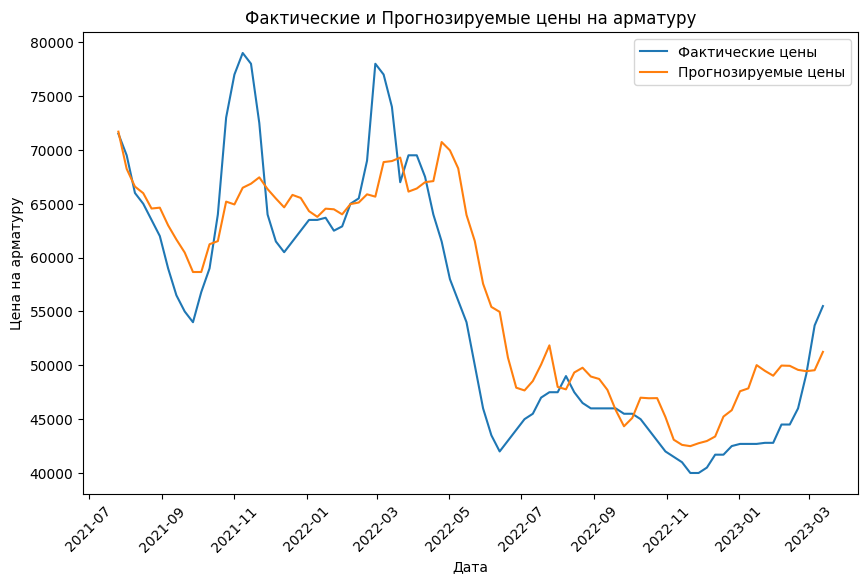

In [74]:
# Визуализация фактических и предсказанных цен
plt.figure(figsize=(10, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Фактические цены")
plt.plot(df["Date"].iloc[-len(y_test):], predictions, label="Прогнозируемые цены")
plt.legend()
plt.xlabel("Дата")
plt.ylabel("Цена на арматуру")
plt.title("Фактические и Прогнозируемые цены на арматуру")
plt.xticks(rotation=45)
plt.show()

In [15]:
import pickle
with open('CatBoost_model.pkl', 'wb') as f: pickle.dump(model, f)

Для сравнения XGB

In [65]:
Xgb = X
Xgb['rolling_mean'] = y.rolling(window=3).mean()

In [66]:
Xgb_train, Xgb_test, ygb_train, ygb_test = train_test_split(Xgb, y, test_size=0.2, shuffle=False)

In [67]:
Xgb_train = Xgb_train.drop('Date', axis=1)
Xgb_test = Xgb_test.drop('Date', axis=1)

In [ ]:
# %pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from math import sqrt

In [68]:
# Определяем модель
xgb_model = XGBRegressor()

# Подгоняем модель на данных
xgb_model.fit(Xgb_train, ygb_train)

# Прогнозируем на тестовых данных
ygb_pred = xgb_model.predict(Xgb_test)

# Оцениваем модель
mae = mean_absolute_error(ygb_test, ygb_pred)
r2 = r2_score(ygb_test, ygb_pred)
rmse = sqrt(mean_squared_error(ygb_test, ygb_pred))

print(f"MAE score: {mae}")
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")

MAE score: 3536.532340116279
R2 score: 0.8434372104425746
RMSE score: 4529.310696091999


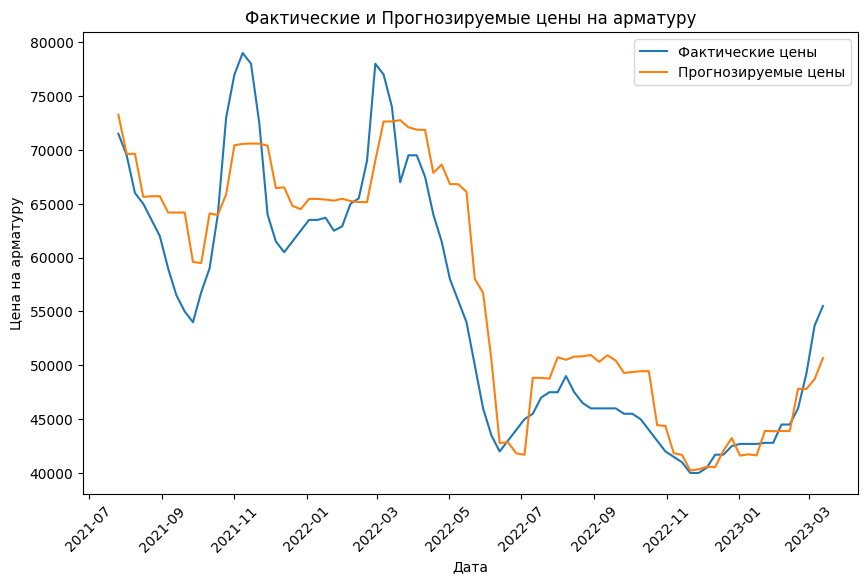

In [69]:
# Визуализация фактических и предсказанных цен
plt.figure(figsize=(10, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Фактические цены")
plt.plot(df["Date"].iloc[-len(y_test):], ygb_pred, label="Прогнозируемые цены")
plt.legend()
plt.xlabel("Дата")
plt.ylabel("Цена на арматуру")
plt.title("Фактические и Прогнозируемые цены на арматуру")
plt.xticks(rotation=45)
plt.show()

In [21]:
import pickle
with open('XGBoost_model.pkl', 'wb') as f: pickle.dump(model, f)

Поиск параметров (не удачный)

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Определяем модель
catboost_model = CatBoostRegressor(verbose=0)

# Определяем сетку параметров для поиска
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

# Определяем метрику для оценки
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Создаем GridSearchCV объект
grid_search = GridSearchCV(estimator=catboost_model, param_grid=param_grid, scoring=scorer, cv=5)

# Подгоняем модель на данных
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры
print("Лучшие параметры: ", grid_search.best_params_)

# Оцениваем модель на тестовых данных
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Лучшие параметры:  {'depth': 4, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
